<a href="https://colab.research.google.com/github/chl-eo/CCDATSCL_ASSIGNMENT/blob/main/Exercise4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 4

This exercise focuses on data visualization and interpretation using a real-world COVID-19 dataset. The dataset contains daily records of confirmed cases, deaths, recoveries, and active cases across countries and regions, along with temporal and geographic information.
The goal of this exercise is not only to create charts, but to choose appropriate visualizations, apply correct data aggregation, and draw meaningful insights from the data. You will work with time-based, categorical, numerical, and geographic variables, and you are expected to think critically about how design choices affect interpretation.

Your visualizations should follow good practices:
- Use clear titles, axis labels, and legends
- Choose chart types appropriate to the data and question
- Avoid misleading scales or cluttered designs
- Clearly explain patterns, trends, or anomalies you observe

Unless stated otherwise, you may filter, aggregate, or group the data as needed.

<img src="https://d3i6fh83elv35t.cloudfront.net/static/2020/03/Screen-Shot-2020-03-05-at-6.29.29-PM-1024x574.png"/>

In [26]:
import kagglehub
import os
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("imdevskp/corona-virus-report")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'corona-virus-report' dataset.
Path to dataset files: /kaggle/input/corona-virus-report


In [27]:
if os.path.isdir(path):
  print(True)

contents = os.listdir(path)
contents

mydataset = path + "/" + contents[0]
mydataset


df = pd.read_csv(mydataset)

True


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


In [58]:
df.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [30]:
df.query("`Country/Region` == 'Philippines'")

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
180,NaN,Philippines,12.879721,121.774017,2020-01-22,0,0,0,0,Western Pacific
441,NaN,Philippines,12.879721,121.774017,2020-01-23,0,0,0,0,Western Pacific
702,NaN,Philippines,12.879721,121.774017,2020-01-24,0,0,0,0,Western Pacific
963,NaN,Philippines,12.879721,121.774017,2020-01-25,0,0,0,0,Western Pacific
1224,NaN,Philippines,12.879721,121.774017,2020-01-26,0,0,0,0,Western Pacific
...,...,...,...,...,...,...,...,...,...,...
47943,NaN,Philippines,12.879721,121.774017,2020-07-23,74390,1871,24383,48136,Western Pacific
48204,NaN,Philippines,12.879721,121.774017,2020-07-24,76444,1879,24502,50063,Western Pacific
48465,NaN,Philippines,12.879721,121.774017,2020-07-25,78412,1897,25752,50763,Western Pacific
48726,NaN,Philippines,12.879721,121.774017,2020-07-26,80448,1932,26110,52406,Western Pacific


## A. Time-Based Visualizations

1. Global Trend `(5 pts)`

Aggregate the data by Date and create a line chart showing the global number of confirmed COVID-19 cases over time.

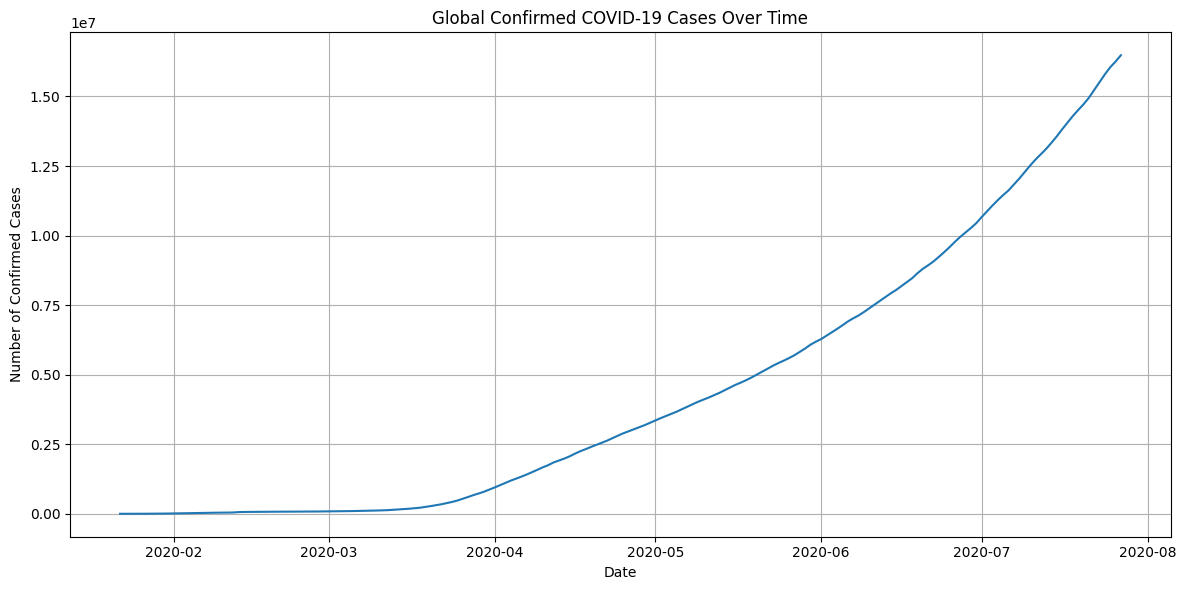

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Aggregate data by Date for global confirmed cases
global_cases = df.groupby('Date')['Confirmed'].sum().reset_index()

# Convert 'Date' column to datetime objects for proper plotting
global_cases['Date'] = pd.to_datetime(global_cases['Date'])

# Create the line chart
plt.figure(figsize=(12, 6))
sns.lineplot(x='Date', y='Confirmed', data=global_cases)
plt.title('Global Confirmed COVID-19 Cases Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Confirmed Cases')
plt.grid(True)
plt.tight_layout()
plt.show()

2. Country-Level Trends `(5 pts)`

Select three countries and visualize their confirmed case counts over time on the same plot.

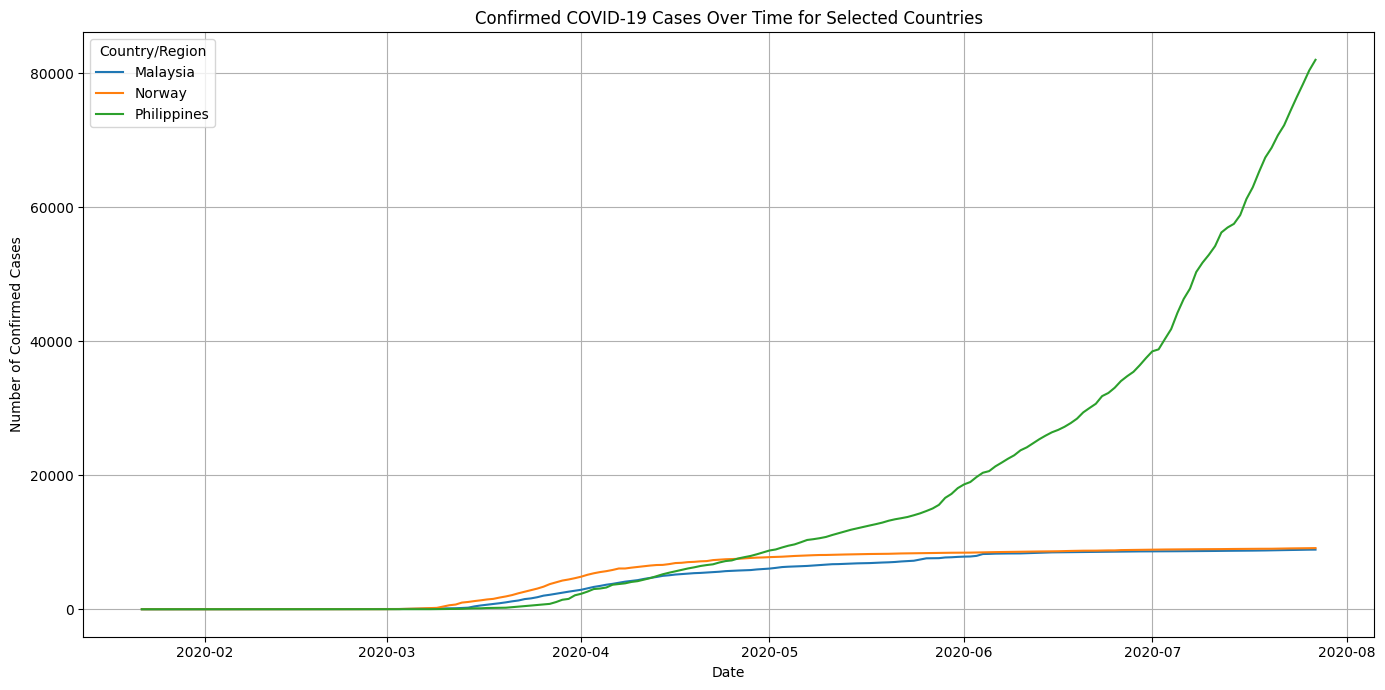

In [32]:
countries = ['Philippines', 'Norway', 'Malaysia']

# Filter the DataFrame for the selected countries
country_cases = df[df['Country/Region'].isin(countries)]

# Aggregate data by Date and Country/Region
country_cases_aggregated = country_cases.groupby(['Date', 'Country/Region'])['Confirmed'].sum().reset_index()

# Convert 'Date' column to datetime objects
country_cases_aggregated['Date'] = pd.to_datetime(country_cases_aggregated['Date'])

# Create the line chart
plt.figure(figsize=(14, 7))
sns.lineplot(x='Date', y='Confirmed', hue='Country/Region', data=country_cases_aggregated)
plt.title('Confirmed COVID-19 Cases Over Time for Selected Countries')
plt.xlabel('Date')
plt.ylabel('Number of Confirmed Cases')
plt.grid(True)
plt.legend(title='Country/Region')
plt.tight_layout()
plt.show()

3. Active vs Recovered `(5 pts)`

For a selected country, create a line chart showing Active and Recovered cases over time.

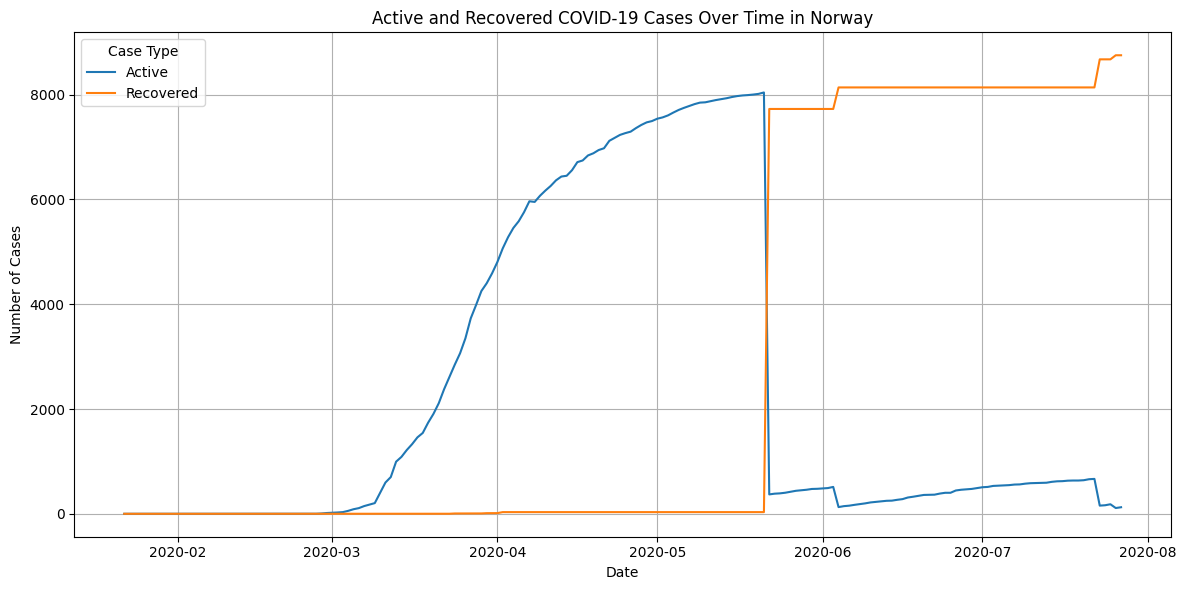

In [33]:
selected_country = 'Norway'

# Filter data for the selected country
country_data = df[df['Country/Region'] == selected_country].copy()

# Convert 'Date' column to datetime objects
country_data['Date'] = pd.to_datetime(country_data['Date'])

# Select relevant columns and melt for easier plotting
melted_data = country_data.melt(id_vars=['Date'], value_vars=['Active', 'Recovered'],
                                   var_name='Case Type', value_name='Count')

# Create the line chart
plt.figure(figsize=(12, 6))
sns.lineplot(x='Date', y='Count', hue='Case Type', data=melted_data)
plt.title(f'Active and Recovered COVID-19 Cases Over Time in {selected_country}')
plt.xlabel('Date')
plt.ylabel('Number of Cases')
plt.grid(True)
plt.legend(title='Case Type')
plt.tight_layout()
plt.show()

## B: Comparative Visualizations

4. Country Comparison `(5 pts)`

Using data from a single date, create a bar chart showing the top 10 countries by confirmed cases.

/tmp/ipython-input-3637962561.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Confirmed', y='Country/Region', data=top_10_countries, palette='viridis')


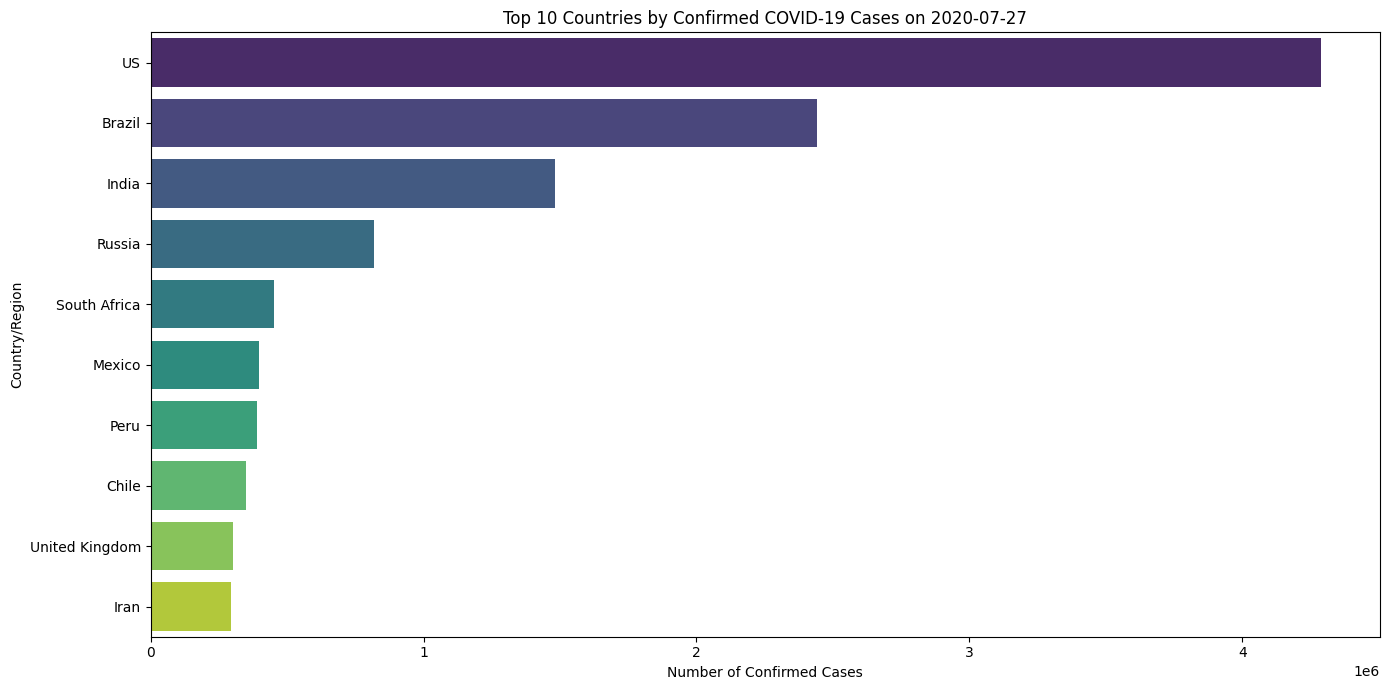

In [34]:
# Select the latest date from the DataFrame
latest_date = df['Date'].max()

# Filter data for the latest date
df_latest_date = df[df['Date'] == latest_date]

# Group by Country/Region and sum Confirmed cases for the latest date
top_countries = df_latest_date.groupby('Country/Region')['Confirmed'].sum().reset_index()

# Sort in descending order and get the top 10 countries
top_10_countries = top_countries.sort_values(by='Confirmed', ascending=False).head(10)

# Create the bar chart
plt.figure(figsize=(14, 7))
sns.barplot(x='Confirmed', y='Country/Region', data=top_10_countries, palette='viridis')
plt.title(f'Top 10 Countries by Confirmed COVID-19 Cases on {latest_date}')
plt.xlabel('Number of Confirmed Cases')
plt.ylabel('Country/Region')
plt.tight_layout()
plt.show()

5. WHO Region Comparison `(5 pts)`

Aggregate confirmed cases by WHO Region and visualize the result using a bar chart.

/tmp/ipython-input-437331456.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Confirmed', y='WHO Region', data=who_region_cases, palette='rocket')


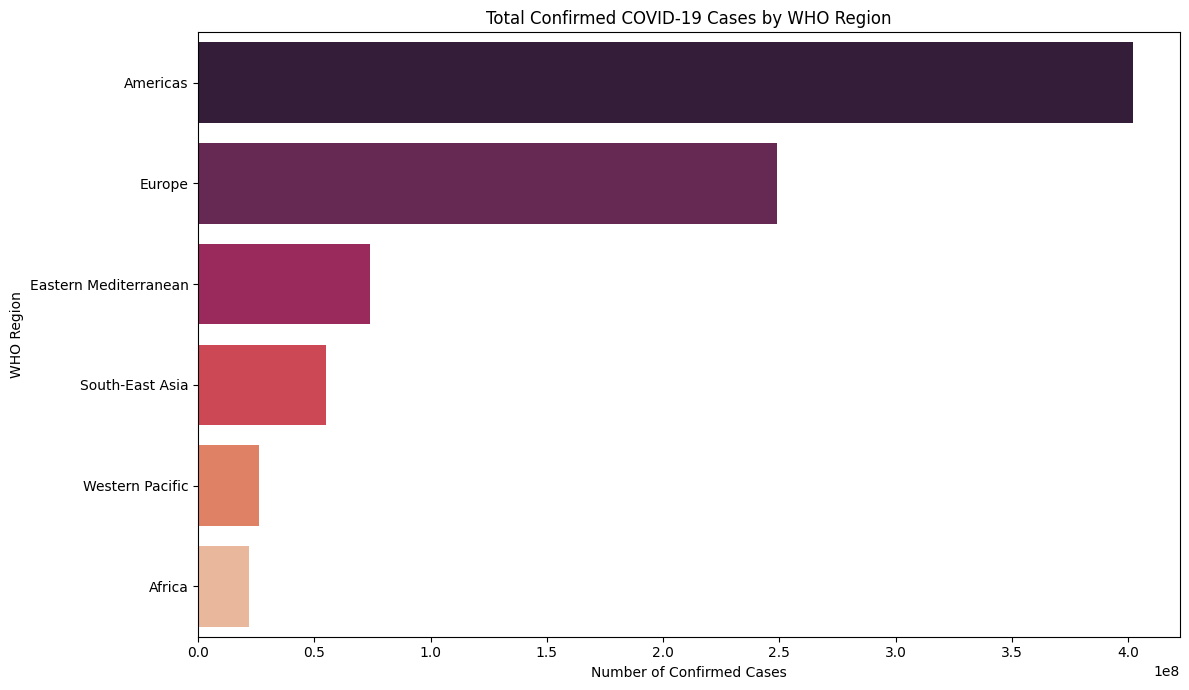

In [35]:
# Aggregate confirmed cases by WHO Region
who_region_cases = df.groupby('WHO Region')['Confirmed'].sum().reset_index()

# Sort the data for better visualization
who_region_cases = who_region_cases.sort_values(by='Confirmed', ascending=False)

# Create the bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x='Confirmed', y='WHO Region', data=who_region_cases, palette='rocket')
plt.title('Total Confirmed COVID-19 Cases by WHO Region')
plt.xlabel('Number of Confirmed Cases')
plt.ylabel('WHO Region')
plt.tight_layout()
plt.show()

## C. Geographic Visualization

6. Geographic Spread `(10 pts)`

Using Latitude and Longitude, create a map-based visualization showing confirmed cases for a selected date.

In [97]:
import pandas as pd
import plotly.express as px
import plotly.io as pio

# Use Colab renderer
pio.renderers.default = "colab"

# Ensure Date is datetime
df["Date"] = pd.to_datetime(df["Date"])

# Select the date to visualize
target_date = "2020-07-27"
df_date = df[df["Date"] == target_date]

# Aggregate by country + coordinates in case of multiple rows per country
agg = df_date.groupby(["Country/Region", "Lat", "Long"], as_index=False)["Confirmed"].sum()

# Create scatter map using latitude/longitude
fig = px.scatter_geo(
    agg,
    lat="Lat",
    lon="Long",
    size="Confirmed",           # Bubble size represents confirmed cases
    color="Confirmed",          # Bubble color represents confirmed cases
    hover_name="Country/Region",
    projection="natural earth",
    title=f"Confirmed COVID-19 Cases on {target_date}",
    color_continuous_scale="PRGn",
    size_max=40                 # Maximum bubble size
)

fig.show()

7. Regional Clustering `(15 pts)`

Create a visualization that shows how confirmed cases are distributed geographically within a single WHO Region.

In [102]:
# put your answer here
import pandas as pd
import plotly.express as px
import plotly.io as pio

pio.renderers.default = "colab"

# Ensure Date is datetime
df["Date"] = pd.to_datetime(df["Date"])

# Select the date to visualize
target_who = "Europe"
df_who = df[df["WHO Region"] == target_who]

# Aggregate by country in case of multiple rows per country
agg = df_who.groupby("Country/Region", as_index=False)["Confirmed"].sum()

# Create choropleth
fig = px.choropleth(
    agg,
    locations="Country/Region",       # Use country names
    locationmode="country names",     # Map by country name
    color="Confirmed",                # Color by confirmed cases
    hover_name="Country/Region",      # Show country on hover
    color_continuous_scale="RdYlGn",  # Color scale
    projection="natural earth",
    title=f"Confirmed COVID-19 Cases on {target_who}"
)

fig.show()